# Project: Vector Visualizer

## 0. Overview

**Problem statement:** Build an interactive 2D and 3D vector visualization toolkit that lets a learner explore all the core vector operations from Part V in one place. This is a capstone tool for Part V — it combines addition, scalar multiplication, dot products, projections, cross products, and transformations into a single runnable system.

**Concepts used from this Part:**
- ch121–126: Vector representation, addition, scalar multiplication
- ch131–134: Dot product, angles, projections
- ch136: Cross product
- ch143: Linear transformations
- ch146–147: Vectorized NumPy operations

**Expected output:** A set of reusable visualization functions and a demo that exercises all of them with interactive parameters.

**Difficulty:** Medium | **Estimated time:** 45–75 minutes

---

## 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

plt.style.use('seaborn-v0_8-whitegrid')

# --- Color palette ---
COLORS = {
    'v1': '#E74C3C',   # red
    'v2': '#2ECC71',   # green
    'v3': '#3498DB',   # blue
    'result': '#9B59B6', # purple
    'projection': '#F39C12',  # orange
    'axis': '#BDC3C7',  # gray
}

def arrow2d(ax, origin, vector, color, label=None, lw=2.5, ls='-'):
    """Draw a 2D arrow from origin in the direction of vector."""
    ax.annotate('', xy=np.array(origin)+np.array(vector),
                xytext=np.array(origin),
                arrowprops=dict(arrowstyle='->', color=color,
                                lw=lw, linestyle=ls))
    if label:
        tip = np.array(origin) + np.array(vector)
        ax.text(tip[0]+0.05, tip[1]+0.05, label, color=color, fontsize=11)

def setup_2d_axes(ax, xlim=(-0.5,3.5), ylim=(-0.5,3.5), title=''):
    ax.set_xlim(*xlim); ax.set_ylim(*ylim)
    ax.axhline(0, color=COLORS['axis'], lw=0.8)
    ax.axvline(0, color=COLORS['axis'], lw=0.8)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=10)

print("Setup complete. All utilities loaded.")

Setup complete. All utilities loaded.


---

## 2. Stage 1 — 2D Vector Operations Visualizer

C:\Users\user\AppData\Local\Temp\ipykernel_9352\287755557.py:83: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_9352\287755557.py:83: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


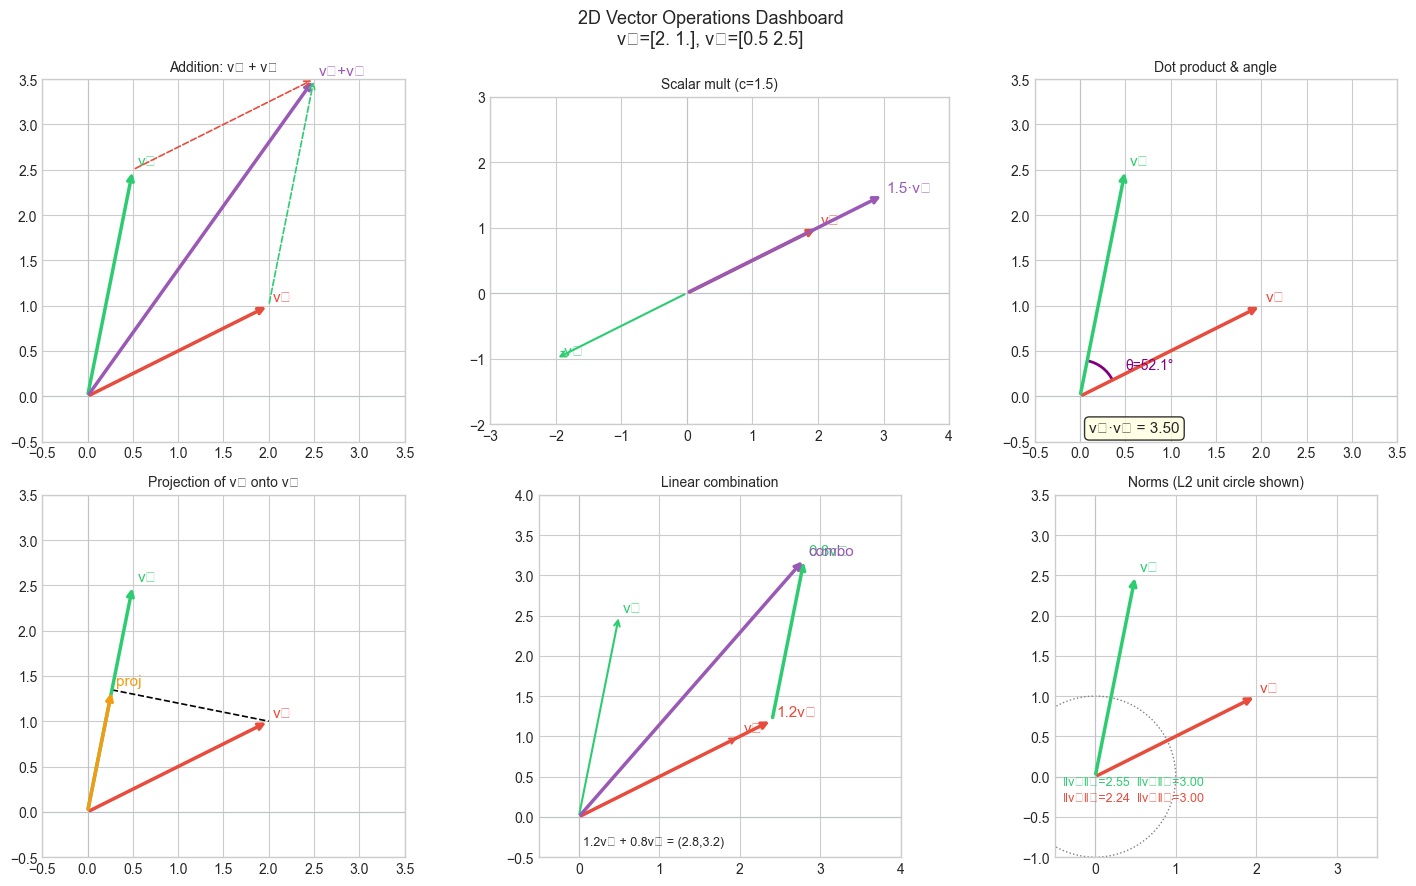

In [2]:
# Stage 1: Visualize all 2D vector operations in one dashboard
# Modify v1 and v2 to explore different configurations.

V1 = np.array([2.0, 1.0])   # <-- modify
V2 = np.array([0.5, 2.5])   # <-- modify
SCALAR = 1.5                 # <-- modify scalar for scalar mult panel

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# --- Panel 1: Vector addition ---
ax = axes[0,0]
arrow2d(ax, [0,0], V1, COLORS['v1'], 'v₁')
arrow2d(ax, [0,0], V2, COLORS['v2'], 'v₂')
arrow2d(ax, [0,0], V1+V2, COLORS['result'], 'v₁+v₂')
# Tip-to-tail
arrow2d(ax, V1, V2, COLORS['v2'], lw=1.2, ls='dashed')
arrow2d(ax, V2, V1, COLORS['v1'], lw=1.2, ls='dashed')
setup_2d_axes(ax, title='Addition: v₁ + v₂')

# --- Panel 2: Scalar multiplication ---
ax = axes[0,1]
arrow2d(ax, [0,0], V1, COLORS['v1'], 'v₁')
arrow2d(ax, [0,0], SCALAR*V1, COLORS['result'], f'{SCALAR}·v₁')
arrow2d(ax, [0,0], -1*V1, COLORS['v2'], '-v₁', lw=1.5)
setup_2d_axes(ax, xlim=(-3,4), ylim=(-2,3), title=f'Scalar mult (c={SCALAR})')

# --- Panel 3: Dot product ---
ax = axes[0,2]
dot = V1 @ V2
angle = np.degrees(np.arccos(np.clip(V1@V2 / (np.linalg.norm(V1)*np.linalg.norm(V2)), -1, 1)))
arrow2d(ax, [0,0], V1, COLORS['v1'], 'v₁')
arrow2d(ax, [0,0], V2, COLORS['v2'], 'v₂')
# Arc for angle
theta1 = np.degrees(np.arctan2(V1[1], V1[0]))
theta2 = np.degrees(np.arctan2(V2[1], V2[0]))
arc = plt.matplotlib.patches.Arc([0,0], 0.8, 0.8,
                                   theta1=min(theta1,theta2), theta2=max(theta1,theta2),
                                   color='purple', lw=2)
ax.add_patch(arc)
ax.text(0.5, 0.3, f'θ={angle:.1f}°', fontsize=10, color='purple')
ax.text(0.1, -0.4, f'v₁·v₂ = {dot:.2f}', fontsize=11,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
setup_2d_axes(ax, title='Dot product & angle')

# --- Panel 4: Projection ---
ax = axes[1,0]
v2_unit = V2 / np.linalg.norm(V2)
proj = (V1 @ v2_unit) * v2_unit
perp = V1 - proj
arrow2d(ax, [0,0], V1, COLORS['v1'], 'v₁')
arrow2d(ax, [0,0], V2, COLORS['v2'], 'v₂')
arrow2d(ax, [0,0], proj, COLORS['projection'], 'proj')
ax.plot([proj[0], V1[0]], [proj[1], V1[1]], 'k--', lw=1.2)
setup_2d_axes(ax, title='Projection of v₁ onto v₂')

# --- Panel 5: Linear combination ---
ax = axes[1,1]
C1, C2 = 1.2, 0.8  # <-- modify coefficients
combo = C1*V1 + C2*V2
arrow2d(ax, [0,0], V1, COLORS['v1'], 'v₁', lw=1.5)
arrow2d(ax, [0,0], V2, COLORS['v2'], 'v₂', lw=1.5)
arrow2d(ax, [0,0], C1*V1, COLORS['v1'], f'{C1}v₁', lw=2.5)
arrow2d(ax, C1*V1, C2*V2, COLORS['v2'], f'{C2}v₂', lw=2.5)
arrow2d(ax, [0,0], combo, COLORS['result'], f'combo')
ax.text(0.05, -0.35, f'{C1}v₁ + {C2}v₂ = ({combo[0]:.1f},{combo[1]:.1f})',
        fontsize=9)
setup_2d_axes(ax, xlim=(-0.5,4), ylim=(-0.5,4), title=f'Linear combination')

# --- Panel 6: Norms ---
ax = axes[1,2]
arrow2d(ax, [0,0], V1, COLORS['v1'], 'v₁')
arrow2d(ax, [0,0], V2, COLORS['v2'], 'v₂')
# Unit circle for reference
theta = np.linspace(0, 2*np.pi, 100)
ax.plot(np.cos(theta), np.sin(theta), ':', color='gray', lw=1)
for v, c, name in [(V1, COLORS['v1'], 'v₁'), (V2, COLORS['v2'], 'v₂')]:
    ax.text(-0.4, -0.3 + 0.2*(name=='v₂'),
            f'‖{name}‖₂={np.linalg.norm(v):.2f}  ‖{name}‖₁={np.sum(np.abs(v)):.2f}',
            fontsize=9, color=c)
setup_2d_axes(ax, xlim=(-0.5,3.5), ylim=(-1,3.5), title='Norms (L2 unit circle shown)')

plt.suptitle(f'2D Vector Operations Dashboard\nv₁={V1}, v₂={V2}', fontsize=13)
plt.tight_layout()
plt.show()

---

## 3. Stage 2 — 3D Vector Operations Visualizer

Orthonormal basis check:
  e1·e2 = 0.000000 (should be 0)
  e1·e3 = 0.000000 (should be 0)
  e2·e3 = 0.000000 (should be 0)
  |e1|=1.0000, |e2|=1.0000, |e3|=1.0000


c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8323 (\N{SUBSCRIPT THREE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


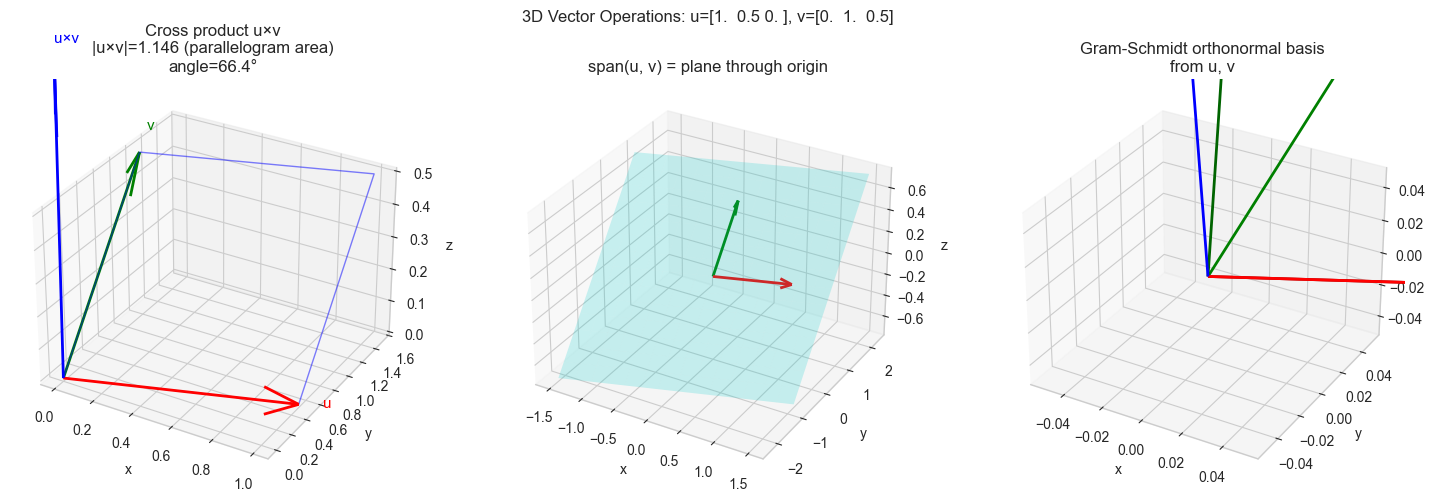

In [3]:
# Stage 2: 3D vector operations — cross product, span, transformations

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

plt.style.use('seaborn-v0_8-whitegrid')

U = np.array([1.0, 0.5, 0.0])   # <-- modify
V = np.array([0.0, 1.0, 0.5])   # <-- modify

cross = np.cross(U, V)
dot_uv = U @ V
angle = np.degrees(np.arccos(np.clip(U@V/(np.linalg.norm(U)*np.linalg.norm(V)),-1,1)))
area = np.linalg.norm(cross)

fig = plt.figure(figsize=(15, 5))

# --- Panel 1: Cross product ---
ax1 = fig.add_subplot(131, projection='3d')
for vec, c, label in [(U,'red','u'), (V,'green','v'), (cross,'blue','u×v')]:
    ax1.quiver(0,0,0,*vec, color=c, lw=2, arrow_length_ratio=0.15)
    ax1.text(*(vec*1.1), label, fontsize=11, color=c)
# Parallelogram
corners = np.array([[0,0,0], U, U+V, V, [0,0,0]])
ax1.plot(corners[:,0], corners[:,1], corners[:,2], 'b-', lw=1, alpha=0.5)
ax1.set_title(f'Cross product u×v\n|u×v|={area:.3f} (parallelogram area)\nangle={angle:.1f}°')
ax1.set_xlabel('x'); ax1.set_ylabel('y'); ax1.set_zlabel('z')

# --- Panel 2: Span visualization ---
ax2 = fig.add_subplot(132, projection='3d')
s = np.linspace(-1.5, 1.5, 15)
S, T = np.meshgrid(s, s)
X = S*U[0] + T*V[0]
Y = S*U[1] + T*V[1]
Z = S*U[2] + T*V[2]
ax2.plot_surface(X, Y, Z, alpha=0.2, color='cyan')
ax2.quiver(0,0,0,*U,color='red',lw=2,arrow_length_ratio=0.15)
ax2.quiver(0,0,0,*V,color='green',lw=2,arrow_length_ratio=0.15)
ax2.set_title('span(u, v) = plane through origin')
ax2.set_xlabel('x'); ax2.set_ylabel('y'); ax2.set_zlabel('z')

# --- Panel 3: Gram-Schmidt orthogonalization ---
ax3 = fig.add_subplot(133, projection='3d')
e1 = U / np.linalg.norm(U)
e2 = V - (V @ e1)*e1
e2 = e2 / np.linalg.norm(e2)
e3 = np.cross(e1, e2)

for vec, c, label in [(U,'red','u (orig)'), (V,'green','v (orig)'),
                       (e1,'darkred','e₁'), (e2,'darkgreen','e₂'), (e3,'blue','e₃=e₁×e₂')]:
    ax3.quiver(0,0,0,*vec,color=c,lw=2,arrow_length_ratio=0.15)
    ax3.text(*(vec*1.1+0.05), label, fontsize=9, color=c)
ax3.set_title('Gram-Schmidt orthonormal basis\nfrom u, v')
ax3.set_xlabel('x'); ax3.set_ylabel('y'); ax3.set_zlabel('z')

# Verify orthonormality
print(f"Orthonormal basis check:")
print(f"  e1·e2 = {e1@e2:.6f} (should be 0)")
print(f"  e1·e3 = {e1@e3:.6f} (should be 0)")
print(f"  e2·e3 = {e2@e3:.6f} (should be 0)")
print(f"  |e1|={np.linalg.norm(e1):.4f}, |e2|={np.linalg.norm(e2):.4f}, |e3|={np.linalg.norm(e3):.4f}")

plt.suptitle(f'3D Vector Operations: u={U}, v={V}', fontsize=12)
plt.tight_layout()
plt.show()

---

## 4. Stage 3 — Transformation Visualizer

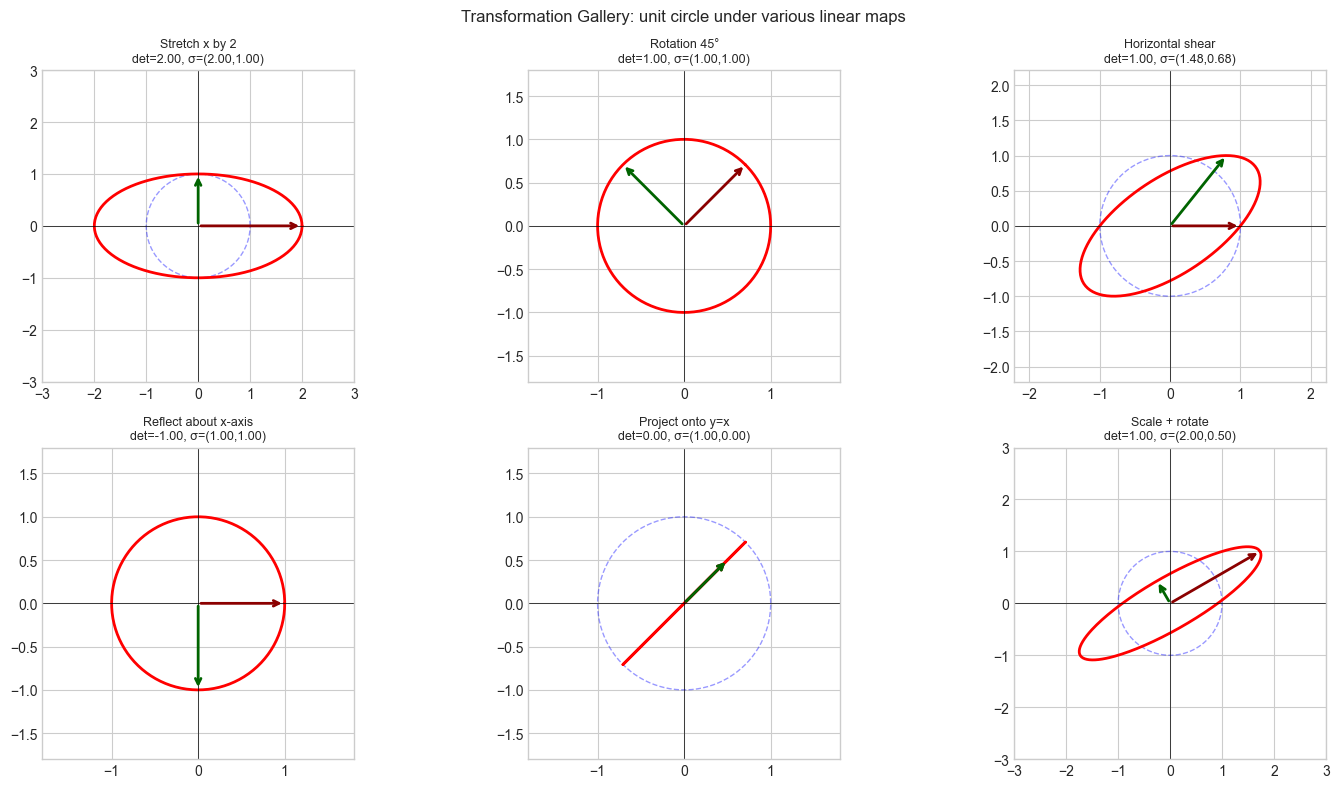

In [4]:
# Stage 3: Visualize how linear transformations deform vector fields

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

def transformation_gallery(matrices_labels, n_cols=3):
    """Visualize a grid of linear transformations applied to a unit circle."""
    n = len(matrices_labels)
    n_rows = (n + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    axes = axes.flat

    # Unit circle + a few test vectors
    theta = np.linspace(0, 2*np.pi, 200)
    circle = np.vstack([np.cos(theta), np.sin(theta)])
    test_vecs = np.array([[1,0],[0,1],[-1,0],[0,-1],[0.7,0.7],[-0.7,0.7]], dtype=float).T

    for ax, (A, label) in zip(axes, matrices_labels):
        # Original (dashed)
        ax.plot(circle[0], circle[1], 'b--', lw=1, alpha=0.4, label='Original')
        # Transformed
        tc = A @ circle
        ax.plot(tc[0], tc[1], 'r-', lw=2, label='Transformed')
        # Transformed basis vectors
        Ae1, Ae2 = A[:,0], A[:,1]
        ax.annotate('', xy=Ae1, xytext=[0,0], arrowprops=dict(arrowstyle='->', color='darkred', lw=2))
        ax.annotate('', xy=Ae2, xytext=[0,0], arrowprops=dict(arrowstyle='->', color='darkgreen', lw=2))

        det = np.linalg.det(A)
        sv = np.linalg.svd(A, compute_uv=False)
        lim = max(sv.max()*1.5, 1.8)
        ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
        ax.set_title(f'{label}\ndet={det:.2f}, σ=({sv[0]:.2f},{sv[1]:.2f})', fontsize=9)
        ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
        ax.set_aspect('equal')

    plt.suptitle('Transformation Gallery: unit circle under various linear maps', fontsize=12)
    plt.tight_layout()
    plt.show()


theta = np.pi / 4
R = lambda t: np.array([[np.cos(t), -np.sin(t)],[np.sin(t), np.cos(t)]])

transformation_gallery([
    (np.array([[2.,0.],[0.,1.]]),       'Stretch x by 2'),
    (R(np.pi/4),                        'Rotation 45°'),
    (np.array([[1.,0.8],[0.,1.]]),       'Horizontal shear'),
    (np.array([[1.,0.],[0.,-1.]]),       'Reflect about x-axis'),
    (np.array([[0.5,0.5],[0.5,0.5]]),    'Project onto y=x'),
    (R(np.pi/6) @ np.array([[2.,0.],[0.,0.5]]), 'Scale + rotate'),
])

---

## 5. Stage 4 — Interactive Summary Panel

In [5]:
# Stage 4: Comprehensive summary panel — any two vectors, all key quantities

import numpy as np

def vector_analysis(v1, v2, name1='v₁', name2='v₂'):
    """
    Print a complete analysis of two vectors covering all Part V concepts.

    Args:
        v1, v2: array-like, shape (2,) or (3,)
    """
    v1, v2 = np.asarray(v1, dtype=float), np.asarray(v2, dtype=float)
    n = len(v1)
    assert len(v1) == len(v2), "Vectors must have the same dimension"

    print(f"Vector Analysis: {name1}={v1}, {name2}={v2}")
    print("=" * 55)

    # Basic operations
    print(f"Addition:          {name1}+{name2} = {v1+v2}")
    print(f"Subtraction:       {name1}-{name2} = {v1-v2}")
    print(f"Scalar mult (×2):  2·{name1} = {2*v1}")

    # Norms
    print(f"\n‖{name1}‖₂ = {np.linalg.norm(v1):.4f}")
    print(f"‖{name2}‖₂ = {np.linalg.norm(v2):.4f}")
    print(f"‖{name1}-{name2}‖₂ = {np.linalg.norm(v1-v2):.4f}  (Euclidean distance)")

    # Dot product and angle
    dot = v1 @ v2
    cos_sim = dot / (np.linalg.norm(v1) * np.linalg.norm(v2))
    angle = np.degrees(np.arccos(np.clip(cos_sim, -1, 1)))
    print(f"\nDot product:       {name1}·{name2} = {dot:.4f}")
    print(f"Cosine similarity: {cos_sim:.4f}")
    print(f"Angle:             {angle:.2f}°")
    print(f"Orthogonal?        {abs(dot) < 1e-9}")

    # Projection
    v2_unit = v2 / np.linalg.norm(v2)
    proj = (v1 @ v2_unit) * v2_unit
    print(f"\nProjection of {name1} onto {name2}: {proj.round(4)}")
    print(f"  Component along {name2}: {v1@v2_unit:.4f}")

    # Cross product (3D only)
    if n == 3:
        cross = np.cross(v1, v2)
        print(f"\nCross product:  {name1}×{name2} = {cross.round(4)}")
        print(f"  |{name1}×{name2}| = {np.linalg.norm(cross):.4f}  (parallelogram area)")
        print(f"  = |{name1}||{name2}|sin(θ) = {np.linalg.norm(v1)*np.linalg.norm(v2)*np.sin(np.radians(angle)):.4f}")

    # Linear independence
    B = np.column_stack([v1, v2])
    rank = np.linalg.matrix_rank(B)
    print(f"\nLinearly independent? {rank == 2}  (rank={rank})")


# --- Run analysis ---
print("Example 1: 2D vectors")
vector_analysis([3, 1], [1, 2])

print("\n" + "="*55)
print("Example 2: 3D vectors")
vector_analysis([1, 0, 0], [0, 1, 0], 'e₁', 'e₂')

print("\n" + "="*55)
print("Example 3: Nearly parallel")
vector_analysis([1, 0.01], [1, 0.02])

Example 1: 2D vectors
Vector Analysis: v₁=[3. 1.], v₂=[1. 2.]
Addition:          v₁+v₂ = [4. 3.]
Subtraction:       v₁-v₂ = [ 2. -1.]
Scalar mult (×2):  2·v₁ = [6. 2.]

‖v₁‖₂ = 3.1623
‖v₂‖₂ = 2.2361
‖v₁-v₂‖₂ = 2.2361  (Euclidean distance)

Dot product:       v₁·v₂ = 5.0000
Cosine similarity: 0.7071
Angle:             45.00°
Orthogonal?        False

Projection of v₁ onto v₂: [1. 2.]
  Component along v₂: 2.2361

Linearly independent? True  (rank=2)

Example 2: 3D vectors
Vector Analysis: e₁=[1. 0. 0.], e₂=[0. 1. 0.]
Addition:          e₁+e₂ = [1. 1. 0.]
Subtraction:       e₁-e₂ = [ 1. -1.  0.]
Scalar mult (×2):  2·e₁ = [2. 0. 0.]

‖e₁‖₂ = 1.0000
‖e₂‖₂ = 1.0000
‖e₁-e₂‖₂ = 1.4142  (Euclidean distance)

Dot product:       e₁·e₂ = 0.0000
Cosine similarity: 0.0000
Angle:             90.00°
Orthogonal?        True

Projection of e₁ onto e₂: [0. 0. 0.]
  Component along e₂: 0.0000

Cross product:  e₁×e₂ = [0. 0. 1.]
  |e₁×e₂| = 1.0000  (parallelogram area)
  = |e₁||e₂|sin(θ) = 1.0000

Linearl

---

## 6. Results & Reflection

**What was built:**
- A 2D vector operations dashboard showing all six core operations on a single figure
- A 3D visualizer for cross product, span, and Gram-Schmidt orthogonalization
- A transformation gallery showing how linear maps deform the unit circle
- A `vector_analysis()` function that computes and narrates all key vector properties

**What math made it possible:**
- Vector addition (ch125): the tip-to-tail diagram
- Dot product and projections (ch131, ch134): angle computation and decomposition
- Cross product (ch136): area and perpendicularity in 3D
- Linear independence (ch141): rank-based test
- Linear transformations (ch143): deformation of the unit circle reveals singular values and determinant

**Extension challenges:**
1. **Animated transformation:** Animate the unit circle morphing from identity to a target transformation matrix by interpolating A(t) = (1-t)·I + t·A. Show how the singular values evolve.
2. **Subspace visualizer:** Extend Stage 2 to visualize the null space and column space of a 3×2 matrix — show which 3D vectors map to zero and which are reachable.
3. **Basis explorer:** Add a widget (or interactive parameter) to Stage 1 that lets the user drag the basis vectors and see how all other quantities update in real time.